In [1]:
## Imports
import numpy as np
import matplotlib.pyplot as plt
import fitsio as fio

## file manager; replace with your own module if needed
%cd /global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/src/statistics/
import corrfiles as cf
import inference as inf
%cd ../statistics/

import sys
project_root ="/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/"
if project_root not in sys.path:
    sys.path.insert(0, project_root)
import src.statistics.inference as inference
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import importlib
import scipy.interpolate as interp

/global/cfs/cdirs/desicollab/users/qlavier/desi-y3-hsc/src/statistics
/global/cfs/cdirs/desicollab/users/qlavier/desi-y3-hsc/src/statistics


In [2]:
# different tests
hscs19a = fio.FITS("/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/hsc/cat/hscs19a_nocut.fits")[1]
print(hscs19a.get_colnames())
print(len(hscs19a.read()))

['object_id', 'ra', 'dec', 'isprimary', 'i_pixelflags_interpolatedcenter', 'i_pixelflags_saturatedcenter', 'i_pixelflags_crcenter', 'i_pixelflags_bad', 'i_pixelflags_suspectcenter', 'i_pixelflags_clipped', 'i_pixelflags_edge', 'g_inputcount_value', 'r_inputcount_value', 'i_inputcount_value', 'z_inputcount_value', 'y_inputcount_value', 'i_cm_mag', 'i_cm_magerr', 'a_i', 'i_cm_flux', 'i_cm_fluxerr', 'e_1', 'e_2', 'weight', 'resolution', 'z_bin', 'b_mode_mask', 'i_apertureflux_10_mag', 'i_detect_isprimary', 'i_deblend_skipped', 'i_extendedness_value', 'i_sdsscentroid_flag', 'i_blendedness_abs', 'i_sdssshape_psf_shape11', 'i_sdssshape_psf_shape22', 'i_sdssshape_shape11', 'i_sdssshape_shape22', 'i_hsmshaperegauss_flag', 'i_hsmshaperegauss_sigma', 'mizuki_photoz_best', 'mizuki_photoz_err95_min', 'mizuki_photoz_err95_max', 'dnnz_photoz_best', 'dnnz_photoz_err95_min', 'dnnz_photoz_err95_max']
35803328


In [ ]:
hscs19a = fio.FITS("/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/hsc/cat/hscy3_cat_withflags.fits")[1]
print(hscs19a.read(['dnnz_photoz_best','z_bin']))

[(2, 0.64) (0, 0.15) (3, 0.98) ... (3, 1.04) (2, 0.77) (1, 0.55)]


In [5]:
importlib.reload(inf)
ROOT = cf.get_base_dir()
CORR_ROOT = ROOT / "src" / "statistics" / "outputs"
stem = "dr2"

path_dictionary = {
    "HSC": CORR_ROOT / "v12_correction" / "autos_HSC",
    "DESI_NGC": CORR_ROOT / stem / "autos_NGC",
    "DESI_SGC": CORR_ROOT / stem / "autos_SGC",
    "DESIxHSC": CORR_ROOT / stem / "cross",
}

patches = [1, 3]
scale_cut = [0.3, 3]
tracer = "QSO"
tomo_bin = 5

fine_edges = cf.CorrFileReader(path_dictionary["DESI_NGC"]).get_bins(tracer)
print(fine_edges)
zlocs = []
dzs = []
wsp_vals, wsp_errs = [], []
wss_vals, wss_errs = [], []
wpp_vals, wpp_errs = [], []

n_z_vals, n_z_errs = [], []
n_z_bs_vals, n_z_bs_errs = [], []
n_z_bs_bp_vals, n_z_bs_bp_errs = [], []

for fine_bin in range(1, len(fine_edges)):
    wsp_meas, wsp_err, wss_meas, wss_err, wpp_meas, wpp_err, deltaz, zloc, n_z, n_z_err, n_z_bs, n_z_bs_err, n_z_bs_bp, n_z_bs_bp_err = inf.compute_npz(
        path_dictionary=path_dictionary,
        tracer=tracer,
        fine_bin=fine_bin,
        tomo_bin=tomo_bin,
        which_patches=patches,
        scale_cuts=scale_cut,
        return_chunks=True,
    )
    
    zloc = (fine_edges[fine_bin] + fine_edges[fine_bin - 1]) / 2
    deltaz = fine_edges[fine_bin] - fine_edges[fine_bin - 1]
    
    zlocs.append(zloc)
    dzs.append(deltaz)
    
    wsp_vals.append(wsp_meas)
    wsp_errs.append(wsp_err)
    wss_vals.append(wss_meas)
    wss_errs.append(wss_err)
    wpp_vals.append(wpp_meas)
    wpp_errs.append(wpp_err)
    
    n_z_vals.append(n_z)
    n_z_errs.append(n_z_err)
    n_z_bs_vals.append(n_z_bs)
    n_z_bs_errs.append(n_z_bs_err)
    n_z_bs_bp_vals.append(n_z_bs_bp)
    n_z_bs_bp_errs.append(n_z_bs_bp_err)

zlocs = np.asarray(zlocs)
print(zlocs)
dzs = np.asarray(dzs)

wsp_vals = np.asarray(wsp_vals)
print(wsp_vals)
wsp_errs = np.asarray(wsp_errs)
print(wsp_errs)
wss_vals = np.asarray(wss_vals)
print(wss_vals)
wss_errs = np.asarray(wss_errs)
print(wss_errs)
wpp_vals = np.asarray(wpp_vals)
print(wpp_vals)
wpp_errs = np.asarray(wpp_errs)
print(wpp_errs)

n_z_vals = np.asarray(n_z_vals)
n_z_errs = np.asarray(n_z_errs)
n_z_bs_vals = np.asarray(n_z_bs_vals)
n_z_bs_errs = np.asarray(n_z_bs_errs)
n_z_bs_bp_vals = np.asarray(n_z_bs_bp_vals)
n_z_bs_bp_errs = np.asarray(n_z_bs_bp_errs)

[0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45
 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15
 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8  2.85
 2.9  2.95 3.  ]
[0.825 0.875 0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375
 1.425 1.475 1.525 1.575 1.625 1.675 1.725 1.775 1.825 1.875 1.925 1.975
 2.025 2.075 2.125 2.175 2.225 2.275 2.325 2.375 2.425 2.475 2.525 2.575
 2.625 2.675 2.725 2.775 2.825 2.875 2.925 2.975]
[ 0.00906563 -0.02439059  0.02018773 -0.0112796   0.00348244 -0.00460546
 -0.01051422 -0.00183383  0.01472951  0.01012973  0.00070889 -0.00439563
 -0.01023156  0.00884793  0.00036341  0.02143282  0.05521412  0.08621343
  0.0547793   0.07703593  0.04498387  0.02197665  0.06271978  0.06605265
  0.04770227  0.04410166  0.03438126  0.01883701  0.04067899  0.03889121
  0.04552811  0.02933515 -0.00402253 -0.0162844   0.03138367  0.01354017
  0.02795129  0.01392276  0.00675617 -0.03284359  0.01160442 -0

In [6]:
# precompute w_dm
fr = cf.CorrFileReader(path_dictionary["DESIxHSC"])
importlib.reload(inference)
bins_z_spectro = inference._get_fine_redshift_bins(fr=fr, tracer=tracer)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array(
    [
        ct.w_dm(
            rp_vals=rp_wdm,
            z=z,  # compute w_dm centered at redshift z
            integrate=True,  # integrate over the scale cuts provided (so on rp_vals)
        )
        for z in vals_z_wdm
    ]
)
wdm_interpolator = interp.interp1d(
    vals_z_wdm, wdm_values, bounds_error=False, fill_value="extrapolate"
)

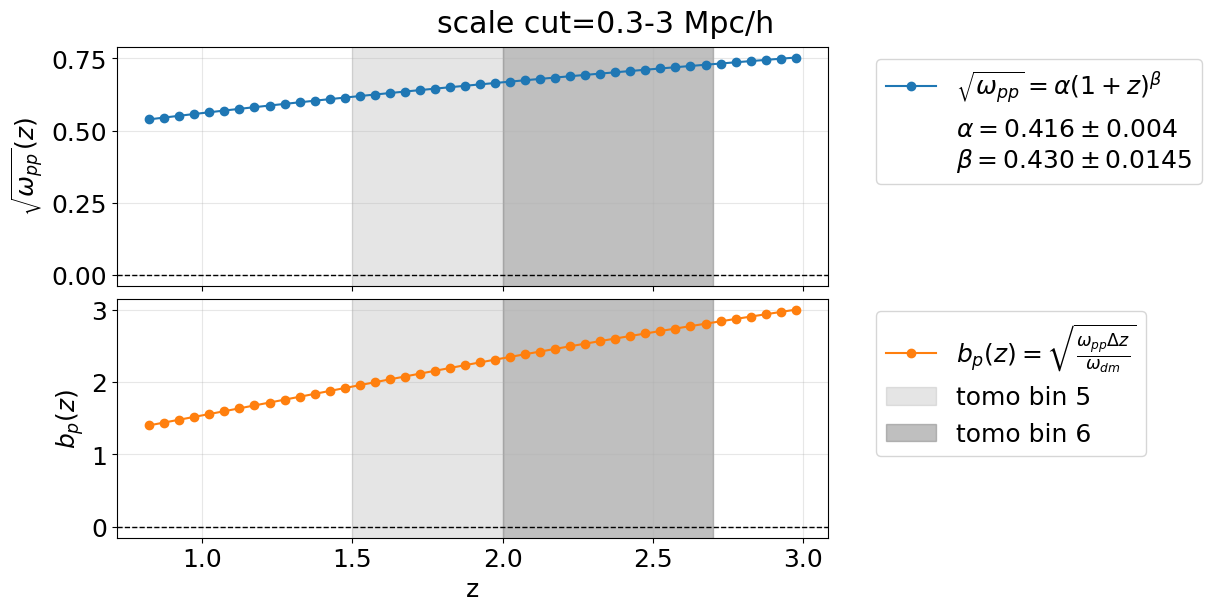

In [ ]:
# plot wpp and bp
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
bin_bounds = {1: (0.3, 0.6), 2: (0.6, 0.9), 3: (0.9, 1.2), 4: (1.2, 1.5), 5: (1.5, 2), 6: (2, 2.7)}

def fill_label(label, i):
    return label + f" {i}" if len(label) > 0 else ""

delta_z = 0.1
wdm_vals = np.array(wdm_interpolator(vals_z_spectro))  # Placeholder for actual wdm values if needed
bp_vals = np.sqrt(wpp_vals*delta_z/wdm_vals)

# `compute_npz(..., return_chunks=True)` currently exposes `wsp` and `wss` directly.
for ax, y, yerr, label, color, label_fill, label_legend in [
    (axes[0], np.sqrt(wpp_vals), wpp_errs, r"$\sqrt{\omega_{pp}}(z)$", "C0", "", r"$\sqrt{\omega_{pp}} = \alpha(1+z)^{\beta}$"),
    (axes[1], bp_vals, wpp_errs, r"$b_p(z)$", "C1", "tomo bin", r"$b_p(z) = \sqrt{\frac{\omega_{pp}\Delta z}{\omega_{dm}}}$"),
]:
  
    plot, = ax.plot(zlocs, y, "o-", color=color, label=label_legend)
    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(label)
    band1 = ax.fill_betweenx([-10, 10], bin_bounds[5][0], bin_bounds[5][1], color="grey", alpha=0.2, label=fill_label(label_fill, 5))
    band2 = ax.fill_betweenx([-10, 10], bin_bounds[6][0], bin_bounds[6][1], color="grey", alpha=0.5, label=fill_label(label_fill, 6))
    handles = [plot]
    if ax == axes[0]:
        param, = axes[0].plot([], [], color="white", label=r"$\alpha = 0.416 \pm 0.004$" "\n" r"$\beta = 0.430 \pm 0.0145$")
        handles.extend([param])

    if label_fill:
        handles.extend([band1, band2])
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
    
axes[-1].set_xlabel("z")
fig.suptitle(
    f"scale cut={scale_cut[0]}-{scale_cut[1]} Mpc/h"
)
plt.show()

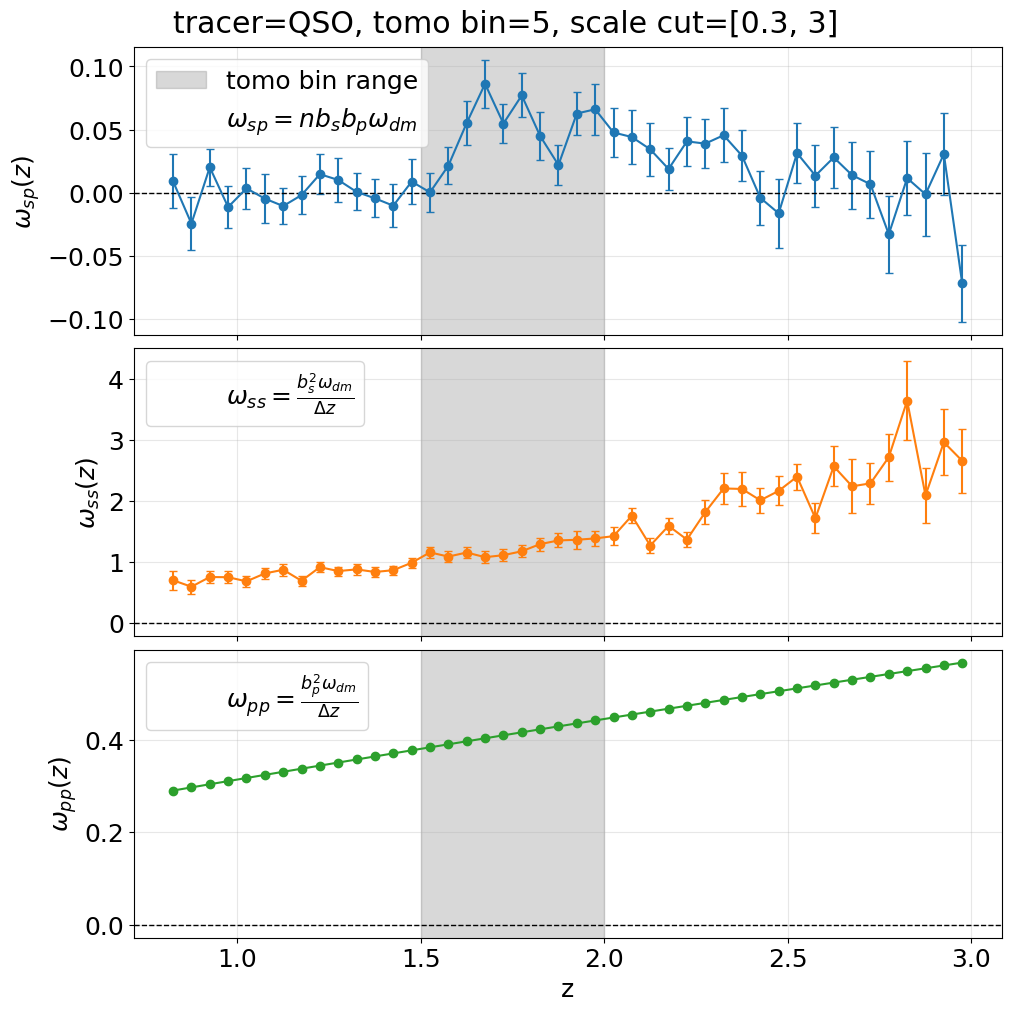

In [ ]:
# plot wsp, wss, wpp
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 10), constrained_layout=True)
bin_bounds = {1: (0.3, 0.6), 2: (0.6, 0.9), 3: (0.9, 1.2), 4: (1.2, 1.5), 5: (1.5, 2), 6: (2, 2.7)}

for ax, y, yerr, label, color, label_fill in [
    (axes[0], wsp_vals, wsp_errs, r"$\omega_{sp}(z)$", "C0", "tomo bin range"),
    (axes[1], wss_vals, wss_errs, r"$\omega_{ss}(z)$", "C1", ""),
    (axes[2], wpp_vals, wpp_errs, r"$\omega_{pp}(z)$", "C2", ""),
]:
    ax.errorbar(zlocs, y, yerr=yerr, fmt="o-", color=color, capsize=3)
    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    ax.fill_betweenx([-10, 10], bin_bounds[tomo_bin][0], bin_bounds[tomo_bin][1], color="grey", alpha=0.3, label=label_fill)
    ax.set_ylabel(label)

axes[0].plot([], [], color="white", label=r"$\omega_{sp} = n b_s b_p \omega_{dm}$")
axes[1].plot([], [], color="white", label=r"$\omega_{ss} = \frac{b_s^2\omega_{dm}}{\Delta z}$")
axes[2].plot([], [], color="white", label=r"$\omega_{pp} = \frac{b_p^2\omega_{dm}}{\Delta z}$")
axes[0].legend()
axes[1].legend()
axes[2].legend()
axes[-1].set_xlabel("z")
fig.suptitle(
    f"tracer={tracer}, data release={stem}, tomo bin={tomo_bin}, scale cut={scale_cut}"
)
plt.show()

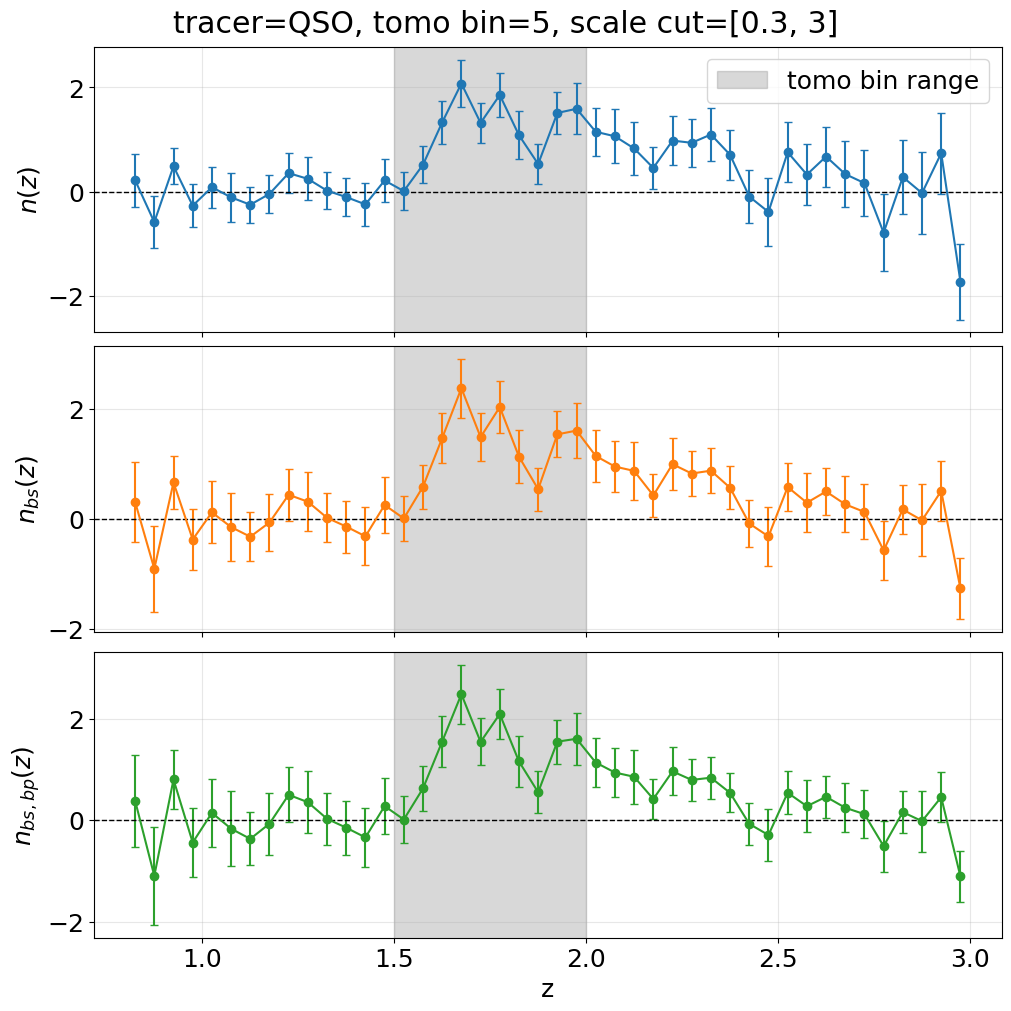

In [ ]:
# plot npz_cross, nz_bs, nz_bs_bp
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 10), constrained_layout=True)
bin_bounds = {1: (0.3, 0.6), 2: (0.6, 0.9), 3: (0.9, 1.2), 4: (1.2, 1.5), 5: (1.5, 2), 6: (2, 2.5), 7: (2.5, 3)}

# `compute_npz(..., return_chunks=True)` currently exposes `wsp` and `wss` directly.
for ax, y, yerr, label, color, label_fill in [
    (axes[0], n_z_vals/np.trapz(n_z_vals, zlocs), n_z_errs/np.trapz(n_z_vals, zlocs), r"$n(z)$", "C0", "tomo bin range"),
    (axes[1], n_z_bs_vals/np.trapz(n_z_bs_vals, zlocs), n_z_bs_errs/np.trapz(n_z_bs_vals, zlocs), r"$n_{bs}(z)$", "C1", ""),
    (axes[2], n_z_bs_bp_vals/np.trapz(n_z_bs_bp_vals, zlocs), n_z_bs_bp_errs/np.trapz(n_z_bs_bp_vals, zlocs), r"$n_{bs,bp}(z)$", "C2", ""),
]:
    ax.errorbar(zlocs, y, yerr=yerr, fmt="o-", color=color, capsize=3)
    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    ax.fill_betweenx([-10, 10], bin_bounds[tomo_bin][0], bin_bounds[tomo_bin][1], color="grey", alpha=0.3, label=label_fill)
    ax.set_ylabel(label)

axes[0].legend()
axes[-1].set_xlabel("z")
fig.suptitle(
    f"tracer={tracer}, data release={stem}, tomo bin={tomo_bin}, scale cut={scale_cut}"
)
plt.show()

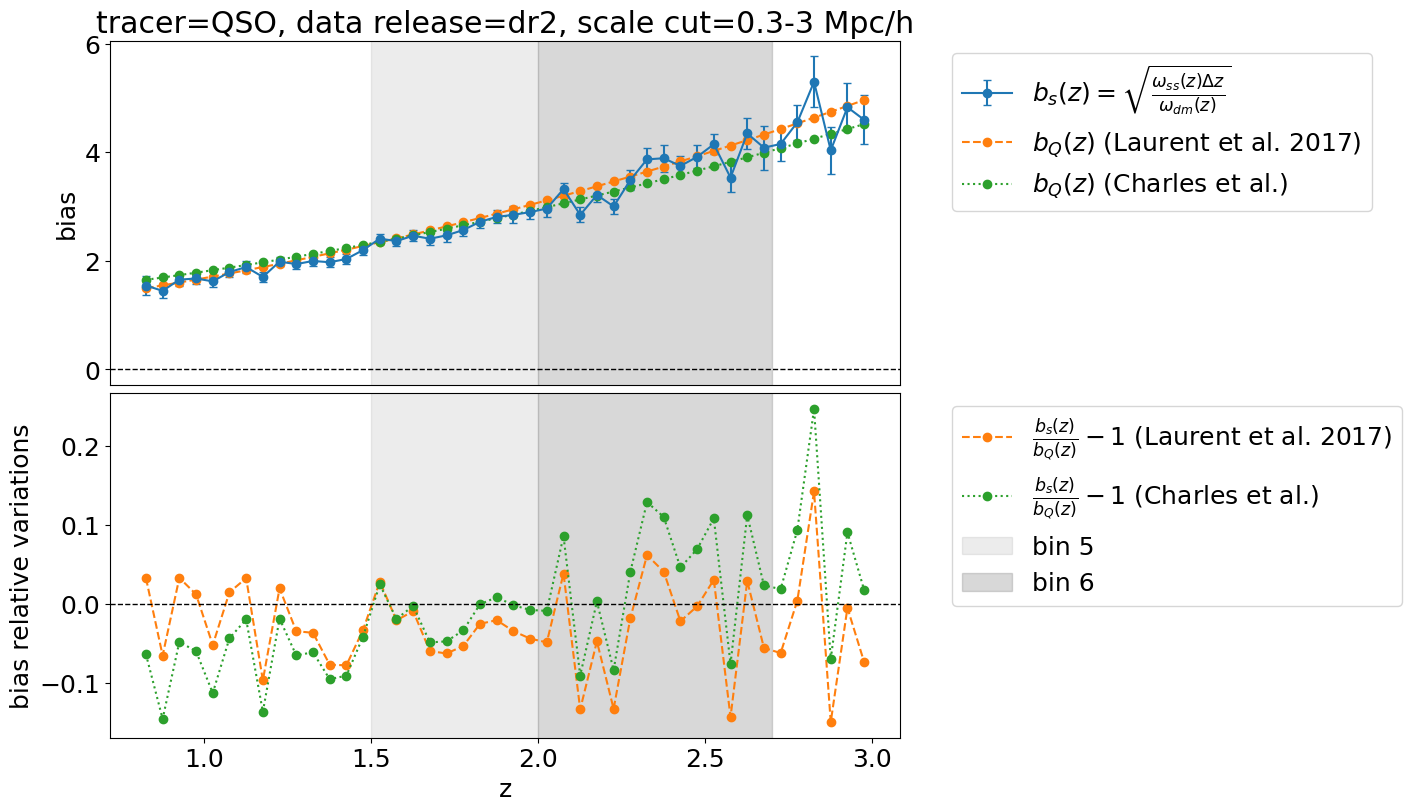

In [17]:
# compare bs, bQ (Laurent), bQ (Charles)
delta_z = 0.05
wdm_vals = np.array(wdm_interpolator(vals_z_spectro))
bs_vals = np.sqrt(wss_vals*delta_z/wdm_vals)
bin_bounds = {1: (0.3, 0.6), 2: (0.6, 0.9), 3: (0.9, 1.2), 4: (1.2, 1.5), 5: (1.5, 2), 6: (2.0, 2.7)}

def b_Q(z):
    a = 0.278
    b = 0.57
    return a*(1+z)**2 + b
def b_Q_bis(z):
    a=0.23
    b=0.23*-6.565+2.394
    return a*(1+z)**2+b

plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

eb = ax1.errorbar(zlocs, bs_vals, yerr=0.5*wss_errs*bs_vals/wss_vals, fmt="o-", capsize=3, label=r"$b_s(z)=\sqrt{\frac{\omega_{ss}(z)\Delta z}{\omega_{dm}(z)}}$")
line, = ax1.plot(zlocs, b_Q(zlocs), "o--", label=r"$b_{Q}(z)$ (Laurent et al. 2017)")
line_bis, = ax1.plot(zlocs, b_Q_bis(zlocs), "o:", label=r"$b_{Q}(z)$ (Charles et al.)")

ax1.axhline(0, color="k", linestyle="--", linewidth=1)
ymin, ymax = ax1.get_ylim()
ax1.set_ylim(ymin, ymax)
ax1.fill_betweenx([-10, 100], bin_bounds[5][0], bin_bounds[5][1], color="grey", alpha=0.15, label="bin 5")
ax1.fill_betweenx([-10, 100], bin_bounds[6][0], bin_bounds[6][1], color="grey", alpha=0.3, label="bin 6")

ax1.set_ylabel("bias")
ax1.set_xticks([])
handles = [eb, line, line_bis]
ax1.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

ax2.plot(zlocs ,bs_vals/b_Q(zlocs)-1, "o--", label=r"$\frac{b_s(z)}{b_{Q}(z)}-1$ (Laurent et al. 2017)", color="C1")
ax2.plot(zlocs ,bs_vals/b_Q_bis(zlocs)-1, "o:", label=r"$\frac{b_s(z)}{b_{Q}(z)}-1 $ (Charles et al.)", color="C2")
ax2.axhline(0, color="k", linestyle="--", linewidth=1)
ymin, ymax = ax2.get_ylim()
ax2.set_ylim(ymin, ymax)
ax2.fill_betweenx([-10, 100], bin_bounds[5][0], bin_bounds[5][1], color="grey", alpha=0.15, label="bin 5")
ax2.fill_betweenx([-10, 100], bin_bounds[6][0], bin_bounds[6][1], color="grey", alpha=0.3, label="bin 6")

ax2.set_xlabel("z")
ax2.set_ylabel("bias relative variations")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax1.set_title(f"tracer={tracer}, data release={stem}, scale cut={scale_cut[0]}-{scale_cut[1]} Mpc/h")
plt.show()

### Compare DR1 & DR2

/!\ make sure that the binning is the same for DR1 & DR2 in the bins_all.npz file in outputs/{stem}/{correlation}/bins folder

In [ ]:
# get wss vals from DR1
importlib.reload(inf)
ROOT = cf.get_base_dir()
CORR_ROOT = ROOT / "src" / "statistics" / "outputs"
stem = "dr1"

path_dictionary = {
    "HSC": CORR_ROOT / "v12_correction" / "autos_HSC",
    "DESI_NGC": CORR_ROOT / stem / "autos_NGC",
    "DESI_SGC": CORR_ROOT / stem / "autos_SGC",
    "DESIxHSC": CORR_ROOT / stem / "cross",
}

patches = [1, 3]
scale_cut = [0.3, 3]
tracer = "QSO"
tomo_bin = 5

fine_edges = cf.CorrFileReader(path_dictionary["DESI_NGC"]).get_bins(tracer)
print(fine_edges)
zlocs = []
dzs = []
wsp_vals, wsp_errs = [], []
wss_vals, wss_errs = [], []
wpp_vals, wpp_errs = [], []

n_z_vals, n_z_errs = [], []
n_z_bs_vals, n_z_bs_errs = [], []
n_z_bs_bp_vals, n_z_bs_bp_errs = [], []

for fine_bin in range(1, len(fine_edges)):
    wsp_meas, wsp_err, wss_meas, wss_err, wpp_meas, wpp_err, deltaz, zloc, n_z, n_z_err, n_z_bs, n_z_bs_err, n_z_bs_bp, n_z_bs_bp_err = inf.compute_npz(
        path_dictionary=path_dictionary,
        tracer=tracer,
        fine_bin=fine_bin,
        tomo_bin=tomo_bin,
        which_patches=patches,
        scale_cuts=scale_cut,
        return_chunks=True,
    )
    
    zloc = (fine_edges[fine_bin] + fine_edges[fine_bin - 1]) / 2
    deltaz = fine_edges[fine_bin] - fine_edges[fine_bin - 1]
    zlocs.append(zloc)
    dzs.append(deltaz)
    wss_vals.append(wss_meas)
    wss_errs.append(wss_err)

zlocs = np.asarray(zlocs)
print(zlocs)
dzs = np.asarray(dzs)

wsp_vals = np.asarray(wsp_vals)
wsp_errs = np.asarray(wsp_errs)
wss_vals_dr1 = np.asarray(wss_vals)
print(wss_vals_dr1)
wss_errs_dr1 = np.asarray(wss_errs)
print(wss_errs_dr1)
wpp_vals = np.asarray(wpp_vals)
wpp_errs = np.asarray(wpp_errs)

n_z_vals = np.asarray(n_z_vals)
n_z_errs = np.asarray(n_z_errs)
n_z_bs_vals = np.asarray(n_z_bs_vals)
n_z_bs_errs = np.asarray(n_z_bs_errs)
n_z_bs_bp_vals = np.asarray(n_z_bs_bp_vals)
n_z_bs_bp_errs = np.asarray(n_z_bs_bp_errs)

In [ ]:
# get wss vals from DR2
importlib.reload(inf)
ROOT = cf.get_base_dir()
CORR_ROOT = ROOT / "src" / "statistics" / "outputs"
stem = "dr2"

path_dictionary = {
    "HSC": CORR_ROOT / "v12_correction" / "autos_HSC",
    "DESI_NGC": CORR_ROOT / stem / "autos_NGC",
    "DESI_SGC": CORR_ROOT / stem / "autos_SGC",
    "DESIxHSC": CORR_ROOT / stem / "cross",
}

patches = [1, 3]
scale_cut = [0.3, 3]
tracer = "QSO"
tomo_bin = 5

fine_edges = cf.CorrFileReader(path_dictionary["DESI_NGC"]).get_bins(tracer)
print(fine_edges)
zlocs = []
dzs = []
wsp_vals, wsp_errs = [], []
wss_vals, wss_errs = [], []
wpp_vals, wpp_errs = [], []

n_z_vals, n_z_errs = [], []
n_z_bs_vals, n_z_bs_errs = [], []
n_z_bs_bp_vals, n_z_bs_bp_errs = [], []

for fine_bin in range(1, len(fine_edges)):
    wsp_meas, wsp_err, wss_meas, wss_err, wpp_meas, wpp_err, deltaz, zloc, n_z, n_z_err, n_z_bs, n_z_bs_err, n_z_bs_bp, n_z_bs_bp_err = inf.compute_npz(
        path_dictionary=path_dictionary,
        tracer=tracer,
        fine_bin=fine_bin,
        tomo_bin=tomo_bin,
        which_patches=patches,
        scale_cuts=scale_cut,
        return_chunks=True,
    )
    
    zloc = (fine_edges[fine_bin] + fine_edges[fine_bin - 1]) / 2
    deltaz = fine_edges[fine_bin] - fine_edges[fine_bin - 1]
    zlocs.append(zloc)
    dzs.append(deltaz)
    wss_vals.append(wss_meas)
    wss_errs.append(wss_err)

zlocs = np.asarray(zlocs)
print(zlocs)
dzs = np.asarray(dzs)

wsp_vals = np.asarray(wsp_vals)
wsp_errs = np.asarray(wsp_errs)
wss_vals_dr2 = np.asarray(wss_vals)
print(wss_vals_dr2)
wss_errs_dr2 = np.asarray(wss_errs)
print(wss_errs_dr2)
wpp_vals = np.asarray(wpp_vals)
wpp_errs = np.asarray(wpp_errs)

n_z_vals = np.asarray(n_z_vals)
n_z_errs = np.asarray(n_z_errs)
n_z_bs_vals = np.asarray(n_z_bs_vals)
n_z_bs_errs = np.asarray(n_z_bs_errs)
n_z_bs_bp_vals = np.asarray(n_z_bs_bp_vals)
n_z_bs_bp_errs = np.asarray(n_z_bs_bp_errs)

In [ ]:
# precompute w_dm
fr = cf.CorrFileReader(path_dictionary["DESIxHSC"])
importlib.reload(inference)
bins_z_spectro = inference._get_fine_redshift_bins(fr=fr, tracer=tracer)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array(
    [
        ct.w_dm(
            rp_vals=rp_wdm,
            z=z,  # compute w_dm centered at redshift z
            integrate=True,  # integrate over the scale cuts provided (so on rp_vals)
        )
        for z in vals_z_wdm
    ]
)
wdm_interpolator = interp.interp1d(
    vals_z_wdm, wdm_values, bounds_error=False, fill_value="extrapolate"
)

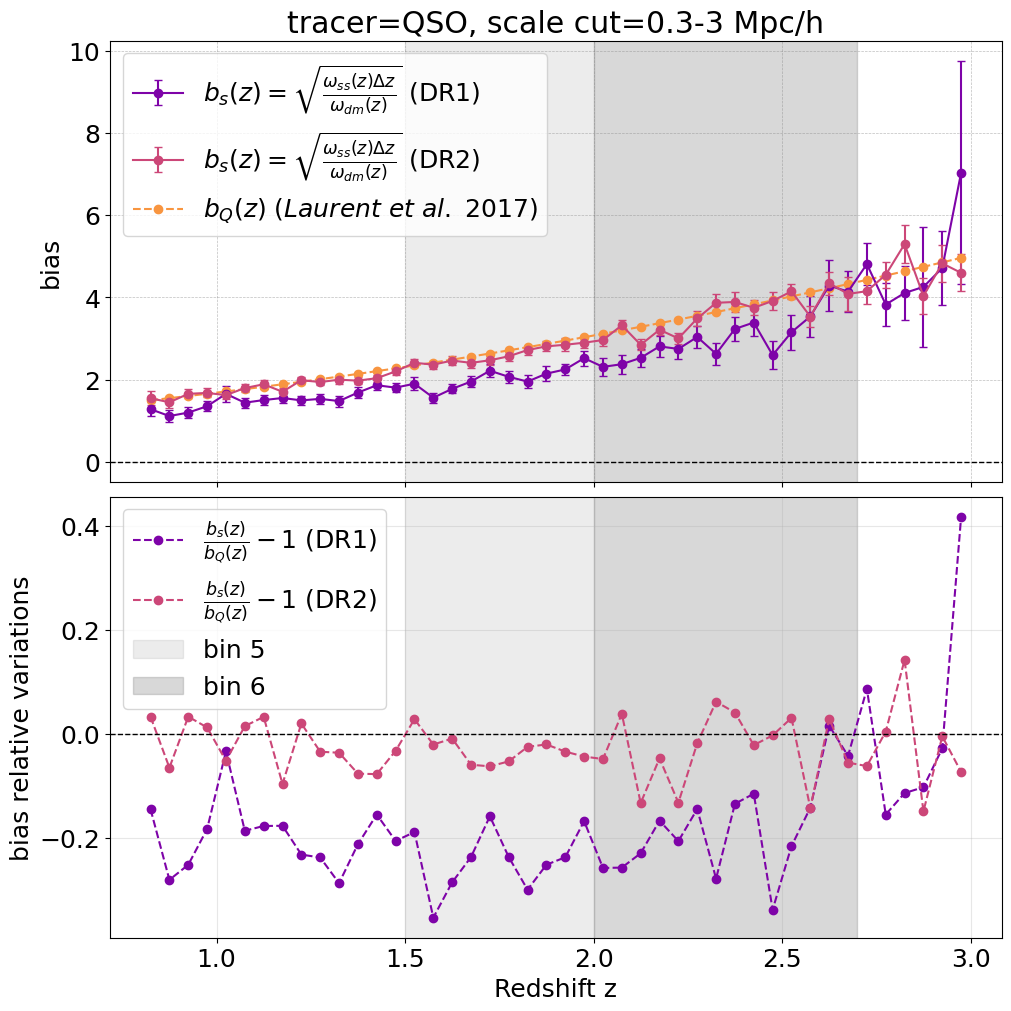

In [ ]:
delta_z = 0.05
wdm_vals = np.array(wdm_interpolator(vals_z_spectro))  # Placeholder for actual wdm values if needed
bs_vals_dr1 = np.sqrt(wss_vals_dr1*delta_z/wdm_vals)
bs_vals_dr2 = np.sqrt(wss_vals_dr2*delta_z/wdm_vals)
bin_bounds = {1: (0.3, 0.6), 2: (0.6, 0.9), 3: (0.9, 1.2), 4: (1.2, 1.5), 5: (1.5, 2.0), 6: (2.0, 2.7)}

def b_Q(z):
    a = 0.278
    b = 0.57
    return a*(1+z)**2 + b

plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True)

cmap = plt.colormaps.get_cmap("plasma")

eb_dr1 = ax1.errorbar(zlocs, bs_vals_dr1, yerr=0.5*wss_errs_dr1*bs_vals_dr1/wss_vals_dr1, color=cmap(0.25), fmt="o-", capsize=3, label=r"$b_s(z)=\sqrt{\frac{\omega_{ss}(z)\Delta z}{\omega_{dm}(z)}}$ (DR1)")
eb_dr2 = ax1.errorbar(zlocs, bs_vals_dr2, yerr=0.5*wss_errs_dr2*bs_vals_dr2/wss_vals_dr2, color=cmap(0.5), fmt="o-", capsize=3, label=r"$b_s(z)=\sqrt{\frac{\omega_{ss}(z)\Delta z}{\omega_{dm}(z)}}$ (DR2)")
line, = ax1.plot(zlocs, b_Q(zlocs),  "o--", color=cmap(0.75), label=r"$b_{Q}(z)$ $\mathit{(Laurent~et~al.~2017)}$")

ax1.axhline(0, color="k", linestyle="--", linewidth=1)
ymin, ymax = ax1.get_ylim()
ax1.set_ylim(ymin, ymax)
ax1.fill_betweenx([-10, 100], bin_bounds[5][0], bin_bounds[5][1], color="grey", alpha=0.15, label="bin 5")
ax1.fill_betweenx([-10, 100], bin_bounds[6][0], bin_bounds[6][1], color="grey", alpha=0.3, label="bin 6")
ax1.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.set_ylabel("bias")
ax1.set_xticklabels([])
ax1.tick_params(axis='x', which='both', labelbottom=False)
handles = [eb_dr1, eb_dr2, line]
ax1.legend(handles=handles)

ax2.plot(zlocs, bs_vals_dr1/b_Q(zlocs)-1, "o--", label=r"$\frac{b_s(z)}{b_{Q}(z)}-1$ (DR1)", color=cmap(0.25))
ax2.plot(zlocs, bs_vals_dr2/b_Q(zlocs)-1, "o--", label=r"$\frac{b_s(z)}{b_{Q}(z)}-1$ (DR2)", color=cmap(0.5))

ax2.axhline(0, color="k", linestyle="--", linewidth=1)
ymin, ymax = ax2.get_ylim()
ax2.set_ylim(ymin, ymax)
ax2.fill_betweenx([-10, 100], bin_bounds[5][0], bin_bounds[5][1], color="grey", alpha=0.15, label="bin 5")
ax2.fill_betweenx([-10, 100], bin_bounds[6][0], bin_bounds[6][1], color="grey", alpha=0.3, label="bin 6")

ax2.set_xlabel("Redshift z")
ax2.set_ylabel("bias relative variations")
ax2.legend(loc='upper left')
ax2.grid(True, which='both', alpha=0.3)
ax1.set_title(f"tracer={tracer}, scale cut={scale_cut[0]}-{scale_cut[1]} Mpc/h")
plt.savefig("/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/src/statistics/scripts_nz/paper_figs/bias_comparison_DR1_DR2.png", dpi=300)
plt.show()